In [1]:
from PIL import Image # Importing the Image module from PIL package.
import numpy as np


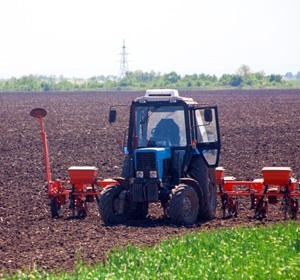

In [2]:
image = Image.open('tractor_img.jpg')
image

In [4]:
image_arr = np.array(image)
image_arr

array([[[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [248, 249, 254],
        [248, 249, 254],
        [248, 249, 254]],

       [[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [248, 249, 254],
        [248, 249, 254],
        [248, 249, 254]],

       [[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [248, 249, 254],
        [248, 249, 254],
        [248, 249, 254]],

       ...,

       [[114, 101,  48],
        [102,  92,  41],
        [119, 117,  68],
        ...,
        [ 66, 108,   0],
        [ 75, 115,   3],
        [ 85, 125,  11]],

       [[150, 134,  75],
        [136, 123,  68],
        [153, 147,  97],
        ...,
        [ 84, 126,  14],
        [ 71, 111,   0],
        [ 90, 130,  15]],

       [[169, 151,  89],
        [203, 188, 129],
        [210, 203, 151],
        ...,
        [ 90, 134,  19],
        [ 73, 113,   0],
        [ 70, 110,   0]]

In [5]:
image_arr.shape

(280, 300, 3)

### Inversion

RGB values take the range $[0, 255]$ for each colour. (0, 0, 0) for (R, G, B) corresponds to black, or the complete absence of colour, while (255, 255, 255) corresponds to white. To invert an image, therefore, we need to subtract each pixel value from 255. Thus, the inversion of white would be black while the inversion of black would be white.

In [7]:
inverted_image_arr = 255 - image_arr

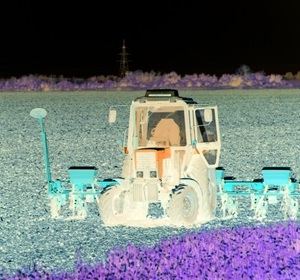

In [10]:
#We can now convert the array back to an image and view it to verify our result
inverted__image = Image.fromarray(inverted_image_arr)
inverted__image

### Convert to greyscale

To convert an image to greyscale, we need to apply a formula which will weigh each channel to arrive at the range of colours that the human eye approximately interprets as grey. The formula is as follows:

$$grey = 0.2989 \cdot R + 0.5870 \cdot G + 0.1140 \cdot B$$

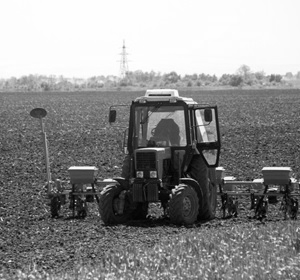

In [13]:
greyscale_image_arr = 0.2989 * image_arr[:, :, 0] + 0.5870 * image_arr[:, :, 1] + 0.1140 * image_arr[:, :, 2]

greyscale_image_arr = greyscale_image_arr.astype(np.uint8)  # as Image.fromarray() cannot handle float values

greyscale_image = Image.fromarray(greyscale_image_arr)
greyscale_image

### Adjusting brightness
Brightness can be adjusted by simply adding more of the colour value to the image. We need to ensure that the range of values does not leave $[0, 255]$; to do this, we can use the `np.clip()` function, which clips values based on lower and upper bounds.

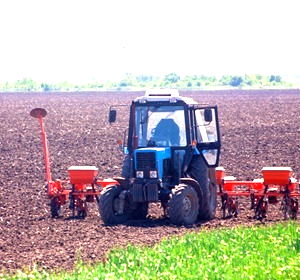

In [16]:
brightness_factor = 1.5  # increasing brightness by 50%
brightened_image_arr = np.clip(image_arr * brightness_factor, 0, 255).astype(np.uint8)

brightened_image = Image.fromarray(brightened_image_arr)
brightened_image

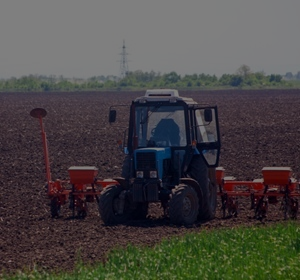

In [15]:
brightness_factor = 0.5  # decreasing brightness by 50%
darkened_image_arr = np.clip(image_arr * brightness_factor, 0, 255).astype(np.uint8)

darkened_image = Image.fromarray(darkened_image_arr)
darkened_image